#### Fine Tuning the Model

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

Accessing the Diabetes prediction classifier

In [2]:
diabetes_df = pd.read_csv("C:/Users/Senthil/Downloads/diabetes_clean.csv")

In [3]:
diabetes_df.head()

,pregnancies,glucose,diastolic,triceps,insulin,bmi,dpf,age,diabetes
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


predict whether or not each individual is likely to have diabetes based on the features body mass index (BMI) and age (in years)

In [4]:
X = diabetes_df[["bmi", "age"]]
y = diabetes_df["diabetes"]

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y)

knn = KNeighborsClassifier(n_neighbors=6)
knn.fit(X_train, y_train)
y_pred = knn.predict(X_test)

print("Confusion Matrix: \n", confusion_matrix(y_test, y_pred))
print("\nClassification Report: \n", classification_report(y_test, y_pred))

Confusion Matrix: 
 [[90 10]
 [41 13]]

Classification Report: 
               precision    recall  f1-score   support

           0       0.69      0.90      0.78       100
           1       0.57      0.24      0.34        54

    accuracy                           0.67       154
   macro avg       0.63      0.57      0.56       154
weighted avg       0.64      0.67      0.62       154



Building a logistic regression model

In [7]:
from sklearn.linear_model import LogisticRegression

logreg = LogisticRegression()
logreg.fit(X_train, y_train)
y_pred_probs = logreg.predict_proba(X_test)

In [8]:
y_pred_probs[:5, :]

array([[0.748787  , 0.251213  ],
       [0.60270545, 0.39729455],
       [0.5604666 , 0.4395334 ],
       [0.35035343, 0.64964657],
       [0.19246472, 0.80753528]])

The ROC curve

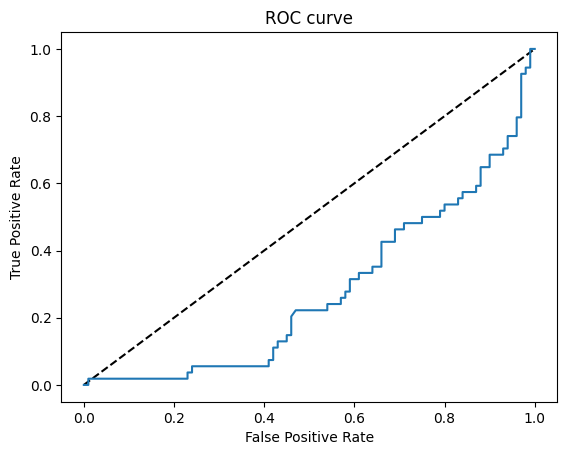

In [9]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_test, y_pred_probs[:, 0])

plt.plot([0, 1], [0, 1], 'k--')
plt.plot(fpr, tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC curve")
plt.show()

The ROC-AUC score

In [ ]:
from sklearn.metrics import roc_auc_score

print(roc_auc_score(y_test, y_pred))
print()
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

0.5538888888888889

[[83 17]
 [39 15]]
              precision    recall  f1-score   support

           0       0.68      0.83      0.75       100
           1       0.47      0.28      0.35        54

    accuracy                           0.64       154
   macro avg       0.57      0.55      0.55       154
weighted avg       0.61      0.64      0.61       154



Hyperparameter tuning with GridSearchCV

In [ ]:
from sklearn.model_selection import KFold, GridSearchCV
from sklearn.linear_model import Lasso

param_grid = {"alpha" : np.linspace(0.00001, 1, 20)}

kf = KFold(n_splits=6, shuffle=True, random_state=42)
lasso = Lasso()
lasso_cv = GridSearchCV(estimator=lasso, param_grid=param_grid, cv=kf)

lasso_cv.fit(X_train, y_train)
y_pred = lasso_cv.predict(X_test)

print(f"Best Parameters: {lasso_cv.best_params_}")
print(f"Best Score: {lasso_cv.best_score_}")

Best Parameters: {'alpha': np.float64(1e-05)}
Best Score: 0.12680459979643888


Hyperparameter Tuning using Randomized Search CV

In [ ]:
from sklearn.model_selection import RandomizedSearchCV

params = {
    "penalty": ["l1", "l2"],
    "tol": np.linspace(0.0001, 1.0, 50),
    "C": np.linspace(0.1, 1.0, 50),
    "class_weight": ["balanced", {0:0.8, 1:0.2}]
}

logreg = LogisticRegression(solver="liblinear")
logreg_cv = RandomizedSearchCV(estimator=logreg, param_distributions=params, cv=kf, n_iter=10)
logreg_cv.fit(X_train, y_train)

print(f"Tuned Logistic Regression best parameters : {logreg_cv.best_params_}")
print(f"Tuned Logistic Regression best score : {logreg_cv.best_score_} ")


c:\Users\Senthil\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\Senthil\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\Senthil\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' wa

Tuned Logistic Regression best parameters : {'tol': np.float64(0.32659795918367346), 'penalty': 'l1', 'class_weight': {0: 0.8, 1: 0.2}, 'C': np.float64(0.46734693877551026)}
Tuned Logistic Regression best score : 0.6513262262833937 


c:\Users\Senthil\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\Senthil\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
c:\Users\Senthil\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of pe